3 Industri Yang Menggunakan Computer Vision 
- Quality Asurance (Mengecek Apakah ada retak?, Apakah Kurang Buat dll)
- Medical (Pengecekan Penyakit Kulit dll)
- Agriculter (Dipakai untuk Mengecek Tanaman , Jumlah Tanaman, Atau penyakit tanaman)

Apa Itu Overfitting pada Manchine Learning?

Overfitting dimana mesin dia menghapal bukan mempelajari, dimana ketika dia mendapatkan data baru yang belum pernah dia akan gagal memprediksi gambar baru tersebut karena terikat dengan data yang lama

Kenapa Bisa Terjadi?
Biasanya diberikan deccision tree tak terbatas , data terlalu sedikit dan minim, dan juga durasi pelatihan terlalu low atau lama

Cara mengatasi?
Dengan menambahkan Jumlah Dataset yang bervariasi , pisahkan antara Train atau data yang dipelajari oleh mesin dengan Data test dimana biasanya menggunakan Learing rate 80% training 20% testing

In [194]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

from torchmetrics.classification import MulticlassAccuracy

import matplotlib.pyplot as plt

from tqdm import tqdm 

from timeit import default_timer as timer

import pandas as pd

print(f"Torch : {torch.__version__} | Torchvision : {torchvision.__version__}")

Torch : 2.13.0+cu130 | Torchvision : 0.28.0+cu130


In [195]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Get datasets MNIST


In [196]:
train_data = datasets.MNIST(
  root="data",
  train=True,
  transform=ToTensor(),
  download=True,
  target_transform=None
)

test_data = datasets.MNIST(
  root="data",
  train=False,
  transform=ToTensor(),
  download=True
)

In [197]:
image, label = train_data[0]

image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [198]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [199]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

Menampilkan 5 Plot Berdasarkan Index

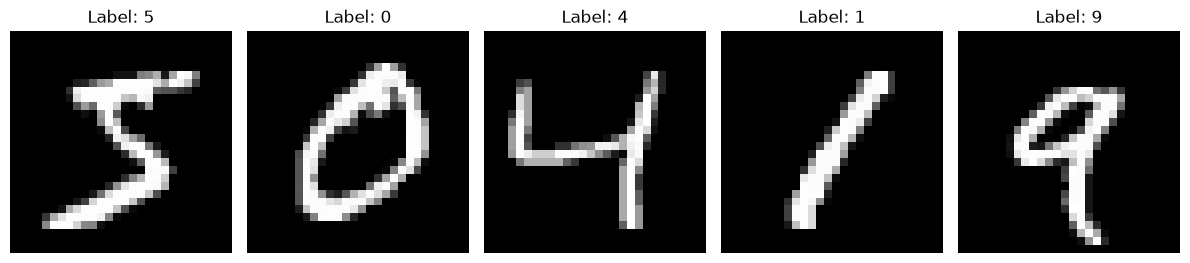

In [200]:
plt.figure(figsize=(12, 3))

for i in range(5):
    image, label = train_data[i]   # Ambil data index ke-i

    plt.subplot(1, 5, i + 1)       # 1 baris, 5 kolom
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Turn into dataloader

In [201]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
  dataset=train_data,
  batch_size=32
)

test_dataloader = DataLoader(
  dataset=test_data,
  batch_size=32
)

In [202]:
train_data_batch , train_label_batch = next(iter(train_dataloader))

train_data_batch.shape, train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Sub Class

In [203]:
class MNISTModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units:int, output_shape:int):
    super().__init__()

    self.block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d( kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

In [204]:
# model input shape berarti shape 1 artinya ubah ke "gray"
model = MNISTModel(input_shape=1, hidden_units=10, output_shape=len(train_data.classes))
model

MNISTModel(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [205]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [206]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
accuracy_fn_cpu = MulticlassAccuracy(num_classes=len(train_data.classes))
accuracy_fn_gpu = MulticlassAccuracy(num_classes=len(train_data.classes)).to(device)

Method Eval Model

In [207]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):

  loss, acc = 0, 0
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {
    "model_name": model.__class__.__name__,
    "model_loss": loss.item(),
    "model_accuracy": acc.item()
  }
  

Train Method

In [208]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss =+ loss
    train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss : {train_loss:.5f} | Train Accuracy : {(train_acc*100):.2f}%")

def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):

  test_loss, test_acc = 0, 0
  model.train()
  for X, y in data_loader:
    X, y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    test_loss += loss
    test_acc += accuracy_fn(y, y_pred.argmax(dim=1))

  test_loss/= len(data_loader)
  test_acc /= len(data_loader)
  print(f"Test Loss : {test_loss:.5f} | Test Accuracy : {(test_acc*100):.2f}%")

Training Data

CPU

In [209]:
torch.manual_seed(42)

epochs = 3

time_start_on_cpu = timer()
for epoch in tqdm(range(epochs)):
  print("Epoch : {epoch} -----------")
  train_step(
    model=model,
    data_loader=train_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn_cpu,
    optimizer=optimizer,
    device="cpu"
  )

  test_step(
    model=model,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn_cpu,
    device="cpu"
  )

time_end_on_cpu = timer()

total_train_time_on_cpu = print_train_time(start=time_start_on_cpu, end=time_end_on_cpu, device="cpu")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : {epoch} -----------
Train Loss : 0.00001 | Train Accuracy : 88.25%


 33%|███▎      | 1/3 [00:14<00:29, 14.57s/it]

Test Loss : 0.09205 | Test Accuracy : 96.73%
Epoch : {epoch} -----------
Train Loss : 0.00001 | Train Accuracy : 97.51%


 67%|██████▋   | 2/3 [00:28<00:14, 14.47s/it]

Test Loss : 0.07112 | Test Accuracy : 97.68%
Epoch : {epoch} -----------
Train Loss : 0.00001 | Train Accuracy : 98.07%


100%|██████████| 3/3 [00:43<00:00, 14.55s/it]

Test Loss : 0.07015 | Test Accuracy : 97.68%
Train time on cpu: 43.646 seconds


In [210]:
eval_model_cpu = eval_model(
  model=model,
  data_loader=test_dataloader,
  accuracy_fn=accuracy_fn_cpu,
  loss_fn=loss_fn,
  device="cpu"
)

eval_model_cpu

{'model_name': 'MNISTModel',
 'model_loss': 0.07015078514814377,
 'model_accuracy': 0.9768452644348145}

GPU (CUDA) Default CUDA

In [211]:
torch.manual_seed(42)

epochs = 3

time_start_on_gpu = timer()
for epoch in tqdm(range(epochs)):
  print("Epoch : {epoch} -----------")
  train_step(
    model=model,
    data_loader=train_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn_gpu,
    optimizer=optimizer,
    device=device
  )

  test_step(
    model=model,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn_gpu,
    device=device
  )

time_end_on_gpu = timer()

total_train_time_on_gpu = print_train_time(start=time_start_on_gpu, end=time_end_on_gpu, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : {epoch} -----------
Train Loss : 0.00000 | Train Accuracy : 98.40%


 33%|███▎      | 1/3 [00:11<00:23, 11.65s/it]

Test Loss : 0.06479 | Test Accuracy : 97.78%
Epoch : {epoch} -----------
Train Loss : 0.00000 | Train Accuracy : 98.57%


 67%|██████▋   | 2/3 [00:23<00:11, 11.65s/it]

Test Loss : 0.06711 | Test Accuracy : 97.62%
Epoch : {epoch} -----------
Train Loss : 0.00000 | Train Accuracy : 98.67%


100%|██████████| 3/3 [00:36<00:00, 12.31s/it]

Test Loss : 0.07207 | Test Accuracy : 97.34%
Train time on cuda: 36.934 seconds


In [212]:
eval_model_gpu = eval_model(
  model=model,
  data_loader=test_dataloader,
  accuracy_fn=accuracy_fn_gpu,
  loss_fn=loss_fn,
  device=device
)

eval_model_gpu

{'model_name': 'MNISTModel',
 'model_loss': 0.07206784188747406,
 'model_accuracy': 0.9734270572662354}

In [213]:
result_df = pd.DataFrame([eval_model_cpu, eval_model_gpu])
result_df

,model_name,model_loss,model_accuracy
0,MNISTModel,0.070151,0.976845
1,MNISTModel,0.072068,0.973427


In [216]:
result_df["training_time"] = [total_train_time_on_cpu, total_train_time_on_gpu]
result_df["device"] = ["CPU", "CUDA"]

result_df

,model_name,model_loss,model_accuracy,training_time,device
0,MNISTModel,0.070151,0.976845,43.646003,CPU
1,MNISTModel,0.072068,0.973427,36.933560,CUDA


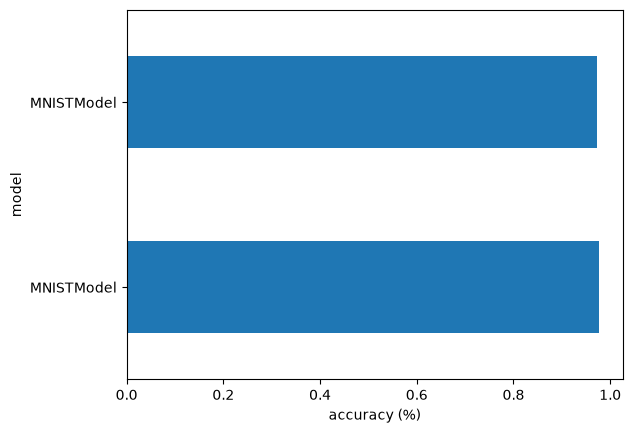

In [217]:
# Visualize our model results
result_df.set_index("model_name")["model_accuracy"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

In [218]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
  pred_probs = []
  model.eval()

  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logit = model(sample)

      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

In [219]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)
  
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (2 - two)


In [220]:
pred_probs = make_predictions(model=model, data=test_samples)

pred_probs[:2]

tensor([[7.5537e-09, 2.0965e-06, 9.9998e-01, 6.6259e-07, 2.5484e-12, 5.6076e-13,
         1.3954e-13, 1.6969e-08, 1.5325e-05, 2.8233e-10],
        [1.4060e-09, 9.9939e-01, 1.2300e-06, 1.9118e-07, 1.0665e-04, 1.8012e-04,
         2.5763e-05, 1.3725e-04, 9.8123e-05, 5.8788e-05]])

In [223]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [224]:
test_labels, pred_classes

([2, 1, 2, 4, 6, 6, 4, 9, 1], tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]))

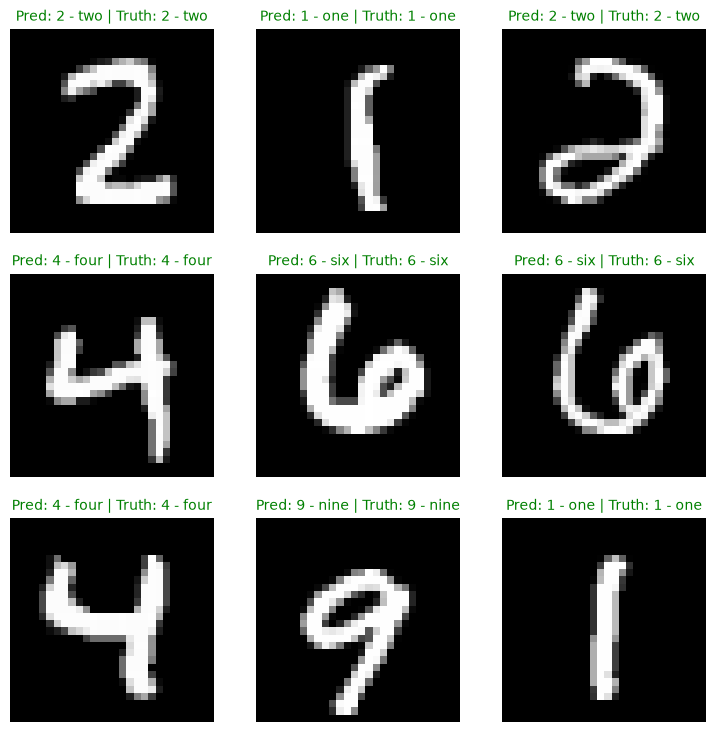

In [225]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

Save Load

In [226]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
model_file_path = MODEL_PATH / "pytorch_computer_vision.pth"

torch.save(model.state_dict(), f=model_file_path)

In [245]:
loaded_model = MNISTModel(input_shape=1, hidden_units=10, output_shape=len(train_data.classes)).to(device)
loaded_model.load_state_dict(torch.load(model_file_path))
loaded_model

MNISTModel(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [249]:
eval_loaded_model = eval_model(
  model=loaded_model,
  data_loader=test_dataloader,
  accuracy_fn=accuracy_fn_gpu,
  loss_fn=loss_fn
)

eval_loaded_model

{'model_name': 'MNISTModel',
 'model_loss': 0.07206784188747406,
 'model_accuracy': 0.9734270572662354}

In [250]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(eval_model_gpu["model_loss"]), 
              torch.tensor(eval_loaded_model["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)